## Data Analysis

In [42]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

In [43]:
# Reading document 1
df = pd.read_csv("Roads.csv")

In [44]:
# Reading document 2
df1 = pd.read_csv("Nigeria_LGAs.csv")

In [45]:
# Information on the first 20 road
df.head(20)

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,Length,AREA_SqKM,Road_density
0,178678000,5114,secondary,NaN,NaN,B,0,1,T,F,0.115,2157.089074,0.0
1,178678001,5114,secondary,NaN,NaN,B,0,1,T,F,0.078,2157.089074,0.0
2,178678002,5114,secondary,NaN,NaN,B,0,0,F,F,6.705,2157.089074,3.0
3,178678004,5114,secondary,NaN,NaN,B,0,0,F,F,18.708,2157.089074,9.0
4,178770907,5121,unclassified,NaN,NaN,B,0,0,F,F,0.597,2157.089074,0.0
5,178770908,5121,unclassified,NaN,NaN,B,0,0,F,F,0.533,2157.089074,0.0
6,178770909,5122,residential,NaN,NaN,B,0,0,F,F,0.454,2157.089074,0.0
7,178770910,5121,unclassified,NaN,NaN,B,0,0,F,F,7.776,2157.089074,4.0
8,178770911,5121,unclassified,NaN,NaN,B,0,0,F,F,0.422,2157.089074,0.0
9,178772354,5115,tertiary,NaN,NaN,B,0,0,F,F,12.082,2157.089074,6.0


In [46]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1787576 entries, 0 to 1787575
Data columns (total 13 columns):
 #   Column        Dtype  
---  ------        -----  
 0   osm_id        int64  
 1   code          int64  
 2   fclass        object 
 3   name          object 
 4   ref           object 
 5   oneway        object 
 6   maxspeed      int64  
 7   layer         int64  
 8   bridge        object 
 9   tunnel        object 
 10  Length        float64
 11  AREA_SqKM     float64
 12  Road_density  float64
dtypes: float64(3), int64(4), object(6)
memory usage: 177.3+ MB


In [47]:
# Merging the two datasets
df2 = pd.merge(df, df1, on='AREA_SqKM', how='inner')

df2

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,...,STATENAME,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,2006,1991
0,178678000,5114,secondary,NaN,NaN,B,0,1,T,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
1,178678001,5114,secondary,NaN,NaN,B,0,1,T,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
2,178678002,5114,secondary,NaN,NaN,B,0,0,F,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
3,178678004,5114,secondary,NaN,NaN,B,0,0,F,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
4,178770907,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780520,1467601535,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Zamfara,Bukkuyum,North_West_Geo-political_Zone,211633.0,Bukkuyum,104977.0,106655.0,National Population Commission,216348,211633
1780521,1469762952,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Zamfara,Bukkuyum,North_West_Geo-political_Zone,211633.0,Bukkuyum,104977.0,106655.0,National Population Commission,216348,211633
1780522,1473906711,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Zamfara,Bukkuyum,North_West_Geo-political_Zone,211633.0,Bukkuyum,104977.0,106655.0,National Population Commission,216348,211633
1780523,1473906712,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Zamfara,Bukkuyum,North_West_Geo-political_Zone,211633.0,Bukkuyum,104977.0,106655.0,National Population Commission,216348,211633


In [48]:
df2 = df2.dropna()

In [49]:
# Dataset information
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4523 entries, 11 to 1777132
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   osm_id        4523 non-null   int64  
 1   code          4523 non-null   int64  
 2   fclass        4523 non-null   object 
 3   name          4523 non-null   object 
 4   ref           4523 non-null   object 
 5   oneway        4523 non-null   object 
 6   maxspeed      4523 non-null   int64  
 7   layer         4523 non-null   int64  
 8   bridge        4523 non-null   object 
 9   tunnel        4523 non-null   object 
 10  Length        4523 non-null   float64
 11  AREA_SqKM     4523 non-null   float64
 12  Road_density  4523 non-null   float64
 13  OBJECTID_1    4523 non-null   int64  
 14  OBJECTID      4523 non-null   int64  
 15  STATENAME     4523 non-null   object 
 16  NAME_1        4523 non-null   object 
 17  Geo_Politi    4523 non-null   object 
 18  Population    4523 non-null  

In [50]:
# Total Road Length
Total_road_length = df2["Length"].sum()

Total_road_length

np.float64(30944.998)

In [51]:
# Average road length
Average_road_length = df2["Length"].mean()

Average_road_length

np.float64(6.84169754587663)

In [52]:
# Road per Capital
df2 ["Road_Per_Capital"] = Total_road_length / df2["Population"]

df2

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\1118846631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2 ["Road_Per_Capital"] = Total_road_length / df2["Population"]


,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,...,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,2006,1991,Road_Per_Capital
11,186052105,5112,trunk,Kaduna-Jos Highway,A236,B,0,0,F,F,...,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161,0.093444
14,186799174,5113,primary,Rahama to Kafin Mayaki Road,F243,B,0,0,F,F,...,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161,0.093444
15,205694168,5112,trunk,Kaduna-Jos Highway,A236,B,0,0,F,F,...,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161,0.093444
21,241570214,5112,trunk,Kaduna-Jos Highway,A236,B,0,1,T,F,...,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161,0.093444
43,276217454,5112,trunk,Kaduna-Jos Highway,A236,B,0,0,F,F,...,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161,0.093444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777128,587984672,5113,primary,Gudau - Sabon Birni Road,F218,B,0,0,F,F,...,Zurmi,North_West_Geo-political_Zone,293837.0,Zurmi,142276.0,151560.0,National Population Commission,293977,293837,0.105313
1777129,587984673,5113,primary,Gudau - Sabon Birni Road,F218,B,0,1,T,F,...,Zurmi,North_West_Geo-political_Zone,293837.0,Zurmi,142276.0,151560.0,National Population Commission,293977,293837,0.105313
1777130,587984674,5113,primary,Gudau - Sabon Birni Road,F218,B,0,0,F,F,...,Zurmi,North_West_Geo-political_Zone,293837.0,Zurmi,142276.0,151560.0,National Population Commission,293977,293837,0.105313
1777131,588252847,5113,primary,Kaura Namoda - Jibiya Road,F137,B,0,1,T,F,...,Zurmi,North_West_Geo-political_Zone,293837.0,Zurmi,142276.0,151560.0,National Population Commission,293977,293837,0.105313


In [53]:
# Longest road
df2.sort_values('Length', ascending=False)

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,...,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,2006,1991,Road_Per_Capital
1748077,294223401,5113,primary,Nguru to Geidam Road,F128,B,0,0,F,F,...,Bursari,North_East_Geo-political_Zone,109124.0,Dapchi,55426.0,53697.0,National Population Commission,109692,109124,0.283576
1721022,294223401,5113,primary,Nguru to Geidam Road,F128,B,0,0,F,F,...,Geidam,North_East_Geo-political_Zone,157295.0,Geidam,82865.0,74429.0,National Population Commission,155740,157295,0.196732
1730493,294223401,5113,primary,Nguru to Geidam Road,F128,B,0,0,F,F,...,Barde,North_East_Geo-political_Zone,139782.0,Gashua,71163.0,68618.0,National Population Commission,139804,139782,0.221380
1750636,294223401,5113,primary,Nguru to Geidam Road,F128,B,0,0,F,F,...,Yunusari,North_East_Geo-political_Zone,125821.0,Kanamga,63077.0,62743.0,National Population Commission,125940,125821,0.245945
720408,560681653,5113,primary,Kano-Gumel Road,F128,B,0,0,F,F,...,Ringim,North_West_Geo-political_Zone,192024.0,Ringim,97678.0,94345.0,National Population Commission,192407,192024,0.161152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083294,593987861,5113,primary,Abaji to Nassarawa Road,F124,B,0,1,T,F,...,Nassarawa,North_Central_Geo-political_Zone,189835.0,Nassarawa,94330.0,95504.0,National Population Commission,187220,189835,0.163010
559193,1433193521,5113,primary,Agbani Link Road,F233,F,0,1,T,F,...,Enugu North,South_East_Geo-political_Zone,244852.0,Enugu,125943.0,118908.0,National Population Commission,242140,244852,0.126382
1562770,1293685378,5112,trunk,Fajuyi Road,A5,F,0,1,T,F,...,Ibadan North West,South_West_Geo-political_Zone,152834.0,Dugbe/Onireke,75336.0,77497.0,National Population Commission,154029,152834,0.202475
1562774,1293685382,5112,trunk,Fajuyi Road,A5,F,0,0,F,F,...,Ibadan North West,South_West_Geo-political_Zone,152834.0,Dugbe/Onireke,75336.0,77497.0,National Population Commission,154029,152834,0.202475


In [54]:
# Road length by LGA
df2.groupby('NAME_1')['Length'].sum()

NAME_1
Aba North       136.389
Aba South       157.574
Abadam          102.340
Abaji            17.551
Abak             28.174
                 ...   
Yunusari        205.873
Zaki            106.473
Zaria            22.436
Zurmi           117.260
kaduna South    122.250
Name: Length, Length: 456, dtype: float64

In [55]:
df2['pressure_index'] = df2['Population'] / df2['Road_density']

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\1595633181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['pressure_index'] = df2['Population'] / df2['Road_density']


In [56]:
df2.sort_values('pressure_index', ascending=False)

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,...,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,2006,1991,Road_Per_Capital,pressure_index
47,276487080,5112,trunk,Kaduna-Jos Highway,A236,B,0,0,F,F,...,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161,0.093444,inf
48,276487081,5112,trunk,Kaduna-Jos Highway,A236,B,0,1,T,F,...,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161,0.093444,inf
1777131,588252847,5113,primary,Kaura Namoda - Jibiya Road,F137,B,0,1,T,F,...,North_West_Geo-political_Zone,293837.0,Zurmi,142276.0,151560.0,National Population Commission,293977,293837,0.105313,inf
87,293130970,5113,primary,Rahama to Kafin Mayaki Road,F243,B,0,1,T,F,...,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161,0.093444,inf
1777129,587984673,5113,primary,Gudau - Sabon Birni Road,F218,B,0,1,T,F,...,North_West_Geo-political_Zone,293837.0,Zurmi,142276.0,151560.0,National Population Commission,293977,293837,0.105313,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000371,134222253,5111,motorway,Third Mainland Bridge,F265,F,100,1,T,F,...,South_West_Geo-political_Zone,209437.0,Lagos Island,105069.0,104367.0,National Population Commission,212700,209437,0.147753,191.092153
714548,182021414,5113,primary,Hadejia to Nguru Road,F128,B,0,0,F,F,...,North_West_Geo-political_Zone,105628.0,Hadejia,54233.0,51394.0,National Population Commission,104286,105628,0.292962,57.468988
714545,182021408,5113,primary,Gumel to Hadejia Road,F128,B,0,0,F,F,...,North_West_Geo-political_Zone,105628.0,Hadejia,54233.0,51394.0,National Population Commission,104286,105628,0.292962,43.792703
740998,278916285,5112,trunk,Enugu - Port Harcourt Expressway,A3-1,F,0,0,F,F,...,South_East_Geo-political_Zone,107488.0,Eziama,53466.0,54021.0,National Population Commission,106844,107488,0.287893,43.289569


In [57]:
# Road count by state
df2.groupby('STATENAME').size()

STATENAME
Abia            88
Adamawa        109
Akwa Ibom       71
Anambra         54
Bauchi         157
Bayelsa         60
Benue           93
Borno          191
Cross River     73
Delta           75
Ebonyi          68
Edo             56
Ekiti           55
Enugu          132
FCT, Abuja     100
Gombe          110
Imo            114
Jigawa          79
Kaduna         219
Kano           213
Katsina         94
Kebbi            4
Kogi            45
Kwara          184
Lagos          522
Nassarawa       80
Niger          103
Ogun           253
Ondo           114
Osun            89
Oyo            243
Plateau        119
Rivers         271
Sokoto          14
Taraba          60
Yobe           122
Zamfara         89
dtype: int64

In [58]:
# Roads per 1000 people
df2['road_per_1000'] = df2['Length'] / (df2['Population'] / 1000)

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\903949296.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['road_per_1000'] = df2['Length'] / (df2['Population'] / 1000)


In [59]:
df2['connectivity_score'] = df2['Road_density'] * 0.6

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\3241024327.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['connectivity_score'] = df2['Road_density'] * 0.6


In [60]:
# Correlation between Population and Length
df2[['Population', 'Length']].corr()

,Population,Length
Population,1.000000,-0.167849
Length,-0.167849,1.000000


In [61]:
gdf = gpd.read_file("Nigerian_LGAs.shp")

# get centroid coordinates
gdf["lon"] = gdf.geometry.centroid.x
gdf["lat"] = gdf.geometry.centroid.y

# export to CSV
gdf[["NAME_1", "lat", "lon"]].to_csv("nigeria_states_coordinates.csv", index=False)

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\2952023825.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["lon"] = gdf.geometry.centroid.x
C:\Users\unity\AppData\Local\Temp\ipykernel_12880\2952023825.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["lat"] = gdf.geometry.centroid.y


In [62]:
df3 = pd.read_csv("nigeria_states_coordinates.csv")
df3

,NAME_1,lat,lon
0,Lere,10.357251,8.572471
1,Zaria,11.037522,7.705616
2,Zangon-Kataf,9.840436,8.236580
3,Birnin-Gwari,10.875143,6.643603
4,Sanga,9.238397,8.500706
...,...,...,...
769,Birnin Magaji/Kiyaw,12.435537,6.895482
770,Gusau,11.810687,6.736948
771,Shinkafi,13.029946,6.497544
772,Zurmi,12.816470,6.767603


In [63]:
df3 = pd.merge(df2, df3, on='NAME_1', how='inner')

In [64]:
df3['STATENAME'].unique()

array(['Kaduna', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa',
       'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo', 'Ekiti',
       'Enugu', 'FCT, Abuja', 'Gombe', 'Imo', 'Jigawa', 'Abia', 'Kano',
       'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nassarawa', 'Niger',
       'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto',
       'Taraba', 'Yobe', 'Zamfara'], dtype=object)

In [65]:
df3['NAME_1'].unique()

array(['Lere', 'Zaria', 'Sabon-Gari', 'Kajuru', 'Igabi', 'Ikara', 'Jaba',
       'Kaduna North', 'Kachia', 'Soba', 'Chikun', 'Makarfi',
       'kaduna South', "Jema'a", 'Kudan', 'Kauru', 'Kagarko', 'Kubau',
       'Yola North', 'Yola South', 'Jada', 'Fufore', 'Ganye',
       'Mubi South', 'Mubi North', 'Girie', 'Maiha', 'Mkpat Enin', 'Abak',
       'Oruk Anam', 'Essien Udim', 'Obot Akara', 'Itu', 'Ikot Ekpene',
       'Ikot Abasi', 'Ikono', 'Ibiono Ibom', 'Uyo', 'Ihiala',
       'Idemili North', 'Onitsha North', 'Awka South', 'Ekwusigo',
       'Idemili South', 'Onitsha South', 'Awka North', 'Bauchi', 'Misau',
       'Itas/Gadau', 'Giade', 'Gamawa', 'Tafawa-Balewa', 'Damban',
       'Shira', 'Katagum', 'Darazo', 'Bogoro', 'Zaki', 'Dass', 'Yenegoa',
       'Sagbama', 'Buruku', 'Oturkpo', 'Agatu', 'Gboko', 'Makurdi',
       'Tarka', 'Oju', 'Logo', 'Apa', 'Ohimini', 'Katsina-Ala', 'Ukum',
       'Guma', 'Damboa', 'Kwaya Kusar', 'Gubio', 'Konduga', 'Marte',
       'Maiduguri', 'Biu', 'Kaga

In [66]:
df3[df3['STATENAME'] == 'FCT, Abuja']['NAME_1'].unique()

array(['Abuja Municipal Area Council', 'Abaji', 'Kuje', 'Gwagwalada'],
      dtype=object)

In [67]:
abuja = df3[
    df3['STATENAME'] == 'FCT, Abuja'
]

In [68]:
abuja['Road_density'] = (
    abuja['Length'] /
    abuja['AREA_SqKM']
)

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\141969864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abuja['Road_density'] = (


In [69]:
abuja['Road_per_capita'] = (
    abuja['Length'] /
    abuja['Population']
)

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\537792700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abuja['Road_per_capita'] = (


In [70]:
abuja['pressure_index'] = (
    abuja['Population'] /
    abuja['Road_density']
)

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\1139806620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abuja['pressure_index'] = (


In [71]:
scaler = MinMaxScaler()

abuja[['road_density_norm',
       'population_norm']] = scaler.fit_transform(
    abuja[['Road_density',
           'Population']]
)

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\4168704587.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abuja[['road_density_norm',
C:\Users\unity\AppData\Local\Temp\ipykernel_12880\4168704587.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abuja[['road_density_norm',


In [72]:
abuja['growth_index'] = (
    0.5 * abuja['road_density_norm'] +
    0.5 * abuja['population_norm']
)

C:\Users\unity\AppData\Local\Temp\ipykernel_12880\701843006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abuja['growth_index'] = (


In [73]:
abuja.sort_values(
    'growth_index',
    ascending=False
)

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,...,Road_Per_Capital,pressure_index,road_per_1000,connectivity_score,lat,lon,Road_per_capita,road_density_norm,population_norm,growth_index
1432,214502508,5112,trunk,Abuja-Kaduna Highway,A2,F,0,0,F,F,...,0.039746,4.958847e+07,0.035680,9.6,8.975748,7.398096,3.567965e-05,0.589691,1.000000,0.794846
1439,214502531,5112,trunk,Abuja-Kaduna Highway,A2,F,0,0,F,F,...,0.039746,5.002972e+07,0.035365,9.6,8.975748,7.398096,3.536497e-05,0.584489,1.000000,0.792244
1413,4871364,5111,motorway,Murtala Mohammed Expressway,A234,F,0,0,F,F,...,0.039746,8.279350e+07,0.021370,5.4,8.975748,7.398096,2.137003e-05,0.353114,1.000000,0.676557
1421,169050478,5111,motorway,Murtala Mohammed Expressway,A234,F,0,0,F,F,...,0.039746,8.298802e+07,0.021320,5.4,8.975748,7.398096,2.131994e-05,0.352286,1.000000,0.676143
1511,214502508,5112,trunk,Abuja-Kaduna Highway,A2,F,0,0,F,F,...,0.196140,5.926409e+06,0.176073,16.2,9.068411,7.024431,1.760728e-04,1.000000,0.137929,0.568965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1488,893303484,5111,motorway,Murtala Mohammed Expressway,A234,F,0,0,F,F,...,0.039746,1.530576e+11,0.000012,0.0,8.975748,7.398096,1.155970e-08,0.000000,1.000000,0.500000
1507,294423109,5113,primary,Abaji to Nassarawa Road,F124,B,0,0,F,F,...,0.529481,3.338810e+06,0.297208,10.8,8.877566,6.853413,2.972076e-04,0.657464,0.000000,0.328732
1510,294423109,5113,primary,Abaji to Nassarawa Road,F124,B,0,0,F,F,...,0.317818,9.216770e+06,0.178397,6.6,8.660453,7.252596,1.783972e-04,0.396711,0.054050,0.225381
1509,356049324,5113,primary,Abaji to Nassarawa Road,F124,F,0,0,F,F,...,0.529481,6.236036e+08,0.001591,0.0,8.877566,6.853413,1.591267e-06,0.003330,0.000000,0.001665


In [74]:
bbox = (7.20, 8.80, 7.65, 9.20)

G = ox.graph_from_bbox(
    bbox=bbox,
    network_type='bike'
)

print(G)

MultiDiGraph with 87148 nodes and 212234 edges


Enter starting location:  FCT
Enter destination:  Kuje


Shortest distance: 41.80313460761143 km


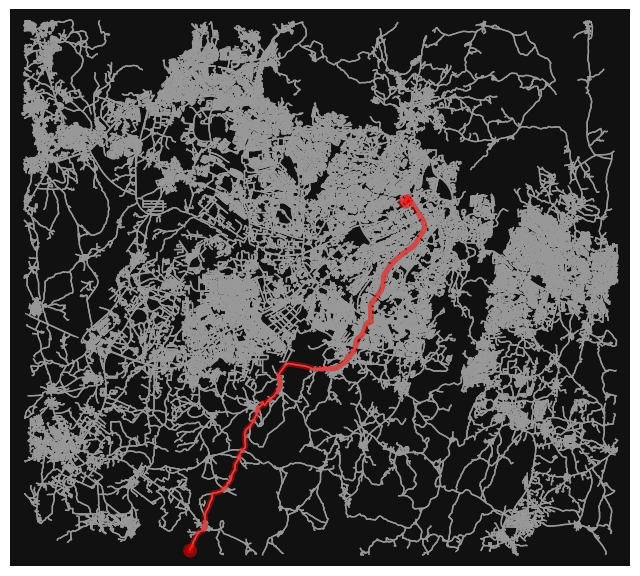

In [75]:
def shortest_route():

    origin = input("Enter starting location: ")
    destination = input("Enter destination: ")

    orig_point = ox.geocode(origin)
    dest_point = ox.geocode(destination)

    orig_node = ox.distance.nearest_nodes(
        G,
        orig_point[1],
        orig_point[0]
    )

    dest_node = ox.distance.nearest_nodes(
        G,
        dest_point[1],
        dest_point[0]
    )

    route = nx.shortest_path(
        G,
        orig_node,
        dest_node,
        weight='length'
    )

    distance = nx.shortest_path_length(
        G,
        orig_node,
        dest_node,
        weight='length'
    )

    print("Shortest distance:", distance / 1000, "km")

    fig, ax = ox.plot_graph_route(
        G,
        route,
        route_linewidth=4,
        node_size=0
    )

shortest_route()

## Data Visualization

In [76]:
df4 = abuja.groupby('NAME_1')[['Length']].sum()
top_LGA = df4.nlargest(10, 'Length')
top_LGA

,Length
NAME_1,
Abuja Municipal Area Council,165.076
Gwagwalada,55.313
Abaji,17.551
Kuje,17.370


<function matplotlib.pyplot.show(close=None, block=None)>

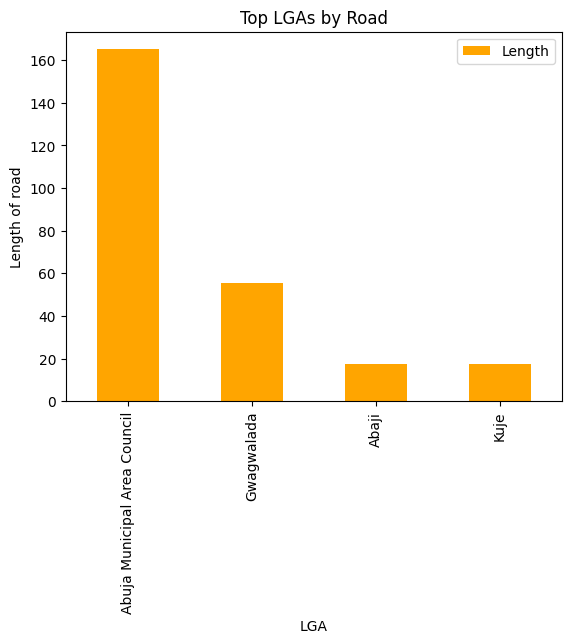

In [77]:
# Barchart showing the top LGAs by Road
top_LGA.plot(kind = 'bar', color = 'orange')
plt.ylabel('Length of road')
plt.xlabel('LGA')
plt.title('Top LGAs by Road')
plt.show

In [78]:
df5 = abuja.groupby('NAME_1')[['Length']].sum()
top_LGA = df5.nlargest(10, 'Length')
top_LGA

,Length
NAME_1,
Abuja Municipal Area Council,165.076
Gwagwalada,55.313
Abaji,17.551
Kuje,17.370


<function matplotlib.pyplot.show(close=None, block=None)>

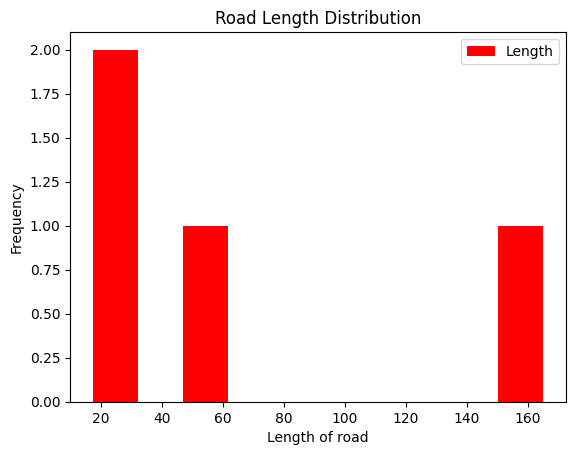

In [79]:
# Histogram showing Road Length Distribution
top_LGA.plot(kind = 'hist', color = 'red')
plt.ylabel('Frequency')
plt.xlabel('Length of road')
plt.title('Road Length Distribution')
plt.show

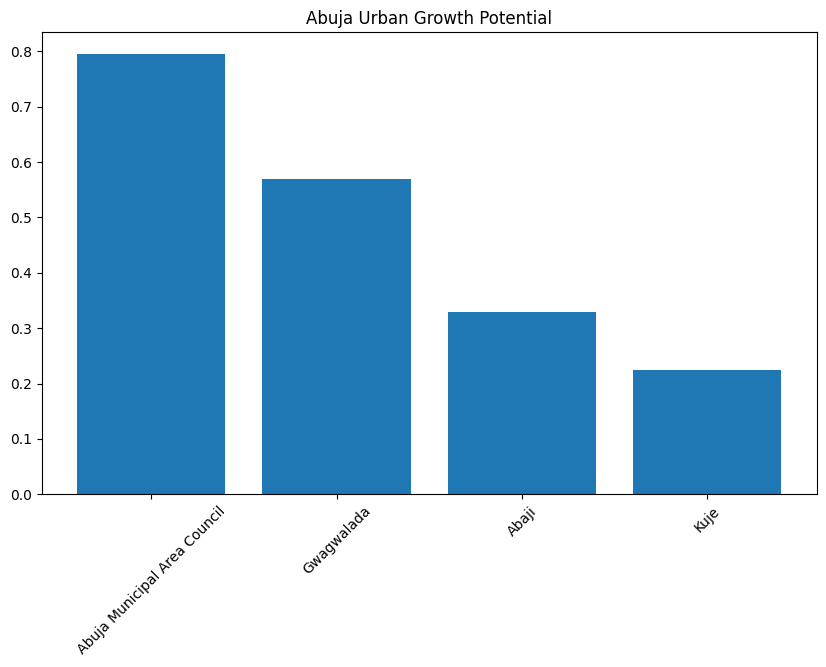

In [80]:
top = abuja.sort_values(
    'growth_index',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.bar(top['NAME_1'], top['growth_index'])

plt.xticks(rotation=45)

plt.title(
    "Abuja Urban Growth Potential"
)

plt.show()

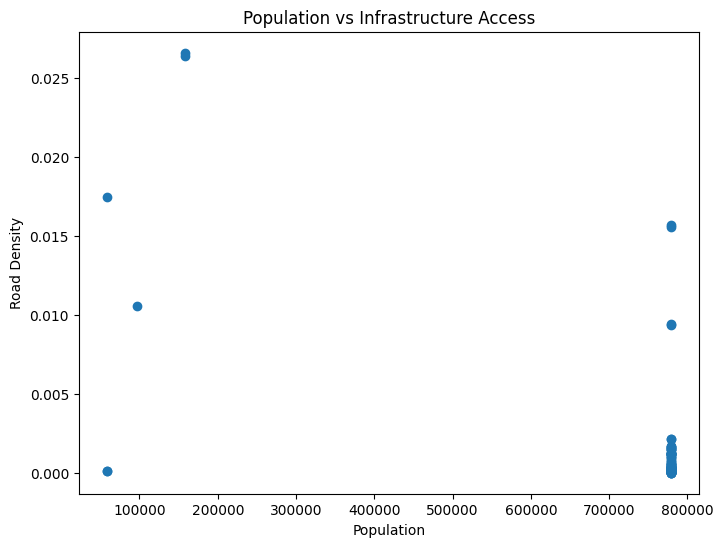

In [81]:
plt.figure(figsize=(8,6))

plt.scatter(
    abuja['Population'],
    abuja['Road_density']
)

plt.xlabel("Population")
plt.ylabel("Road Density")

plt.title(
    "Population vs Infrastructure Access"
)

plt.show()

In [82]:
df3.to_csv("Nigeria Road Network.csv")